In [190]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [191]:
import logging
import os

import matplotlib.pyplot as plt  # type: ignore
import numpy as np

import lenspyx
import healpy as hp
from tqdm.notebook import tqdm

from pixell import curvedsky, enmap, reproject

from scripts import Core
from scripts.utils import (
    remove_mono_dipole,
    setup_logging,
    plot_cl_alm,
    plot_patches,
    plot_cl,
    plot_predictions,
    plot_histogram,
)

from notebooks.ksw_joblib import KSW_joblib

In [192]:
logger = setup_logging(__name__, level=logging.DEBUG)

## Heidelberg test

This downloads the elsner (heidelberg) sims and prints them out as a test comparision for the linear and non-linear alms.

To download uncomment the first cell, the second cell will just plot the sims. You only need the first sim if it is taking a long time.

In [193]:
# import requests

# for num in range(1, 1001):
#     URL1 = (
#         "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_l_"
#         + str(num).zfill(4)
#         + "_v3.fits"
#     )
#     URL2 = (
#         "https://dc.zah.uni-heidelberg.de/elsnersim/q/s/static/alm_nl_"
#         + str(num).zfill(4)
#         + "_v3.fits"
#     )

#     with requests.Session() as s, open(
#         "data/heidelberg/alm_l_" + str(num).zfill(4) + "_v3.fits", "wb"
#     ) as f:
#         f.write(s.get(URL1).content)

#     with requests.Session() as s, open(
#         "data/heidelberg/alm_nl_" + str(num).zfill(4) + "_v3.fits", "wb"
#     ) as f:
#         f.write(s.get(URL2).content)

#     print(f"Finished {num}")

# plot some to see
# arr = []
# for i in range(20):
#     idx = str(1).zfill(4)
#     data = hp.read_alm(f"data/heidelberg/alm_nl_{idx}_v3.fits", hdu=(1, 2, 3))
#     arr.append(np.array(data * t_scale))
# arr = np.array(arr)

# for pol in range(core.npol):
#     plot_cl_alm(arr[:, pol], title=f"pol: {pol}")

20-Jul-24 19:31:41 - scripts.core - DEBUG - Parsing CLI args: ['settings/heidelberg.json', '--nsims', '1', '--narray', '1', '--fnl_range', '-10', '10', '--no-noise', '--pols']
20-Jul-24 19:31:41 - scripts.core - INFO - Loading settings from file settings/heidelberg.json
20-Jul-24 19:31:41 - scripts.core - DEBUG - Forcing setting 'nsims' to '1' due to CLI
20-Jul-24 19:31:41 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI
20-Jul-24 19:31:41 - scripts.core - DEBUG - Forcing setting 'fnl_range' to '[-10.0, 10.0]' due to CLI
20-Jul-24 19:31:41 - scripts.core - DEBUG - Forcing setting 'noise' to 'False' due to CLI
20-Jul-24 19:31:41 - scripts.core - DEBUG - Forcing setting 'pols' to 'True' due to CLI
20-Jul-24 19:31:41 - scripts.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 70.1, 'As': 2.457e-09, 'pivot_scalar': 0.002, 'ns': 0.96, 'ombh2': 0.02256, 'omch2': 0.1143, 'tau': 0.084, 'lmax': 1024} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.0

Alm_ng:   0%|          | 0/1 [00:00<?, ?it/s]

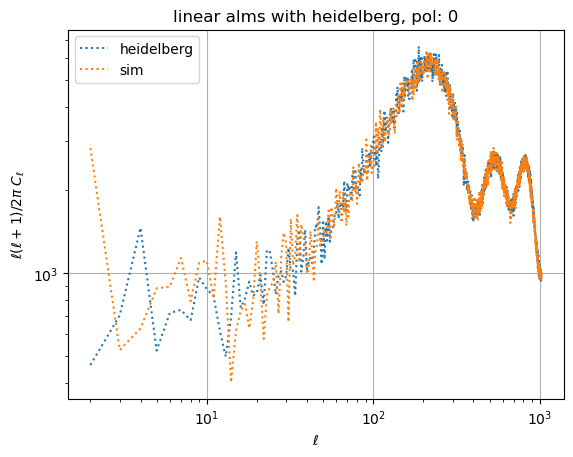

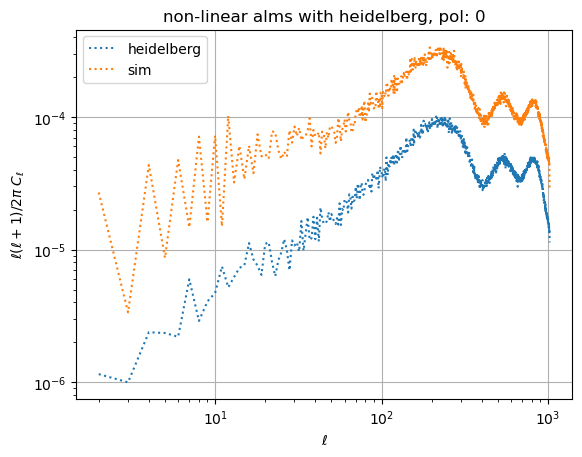

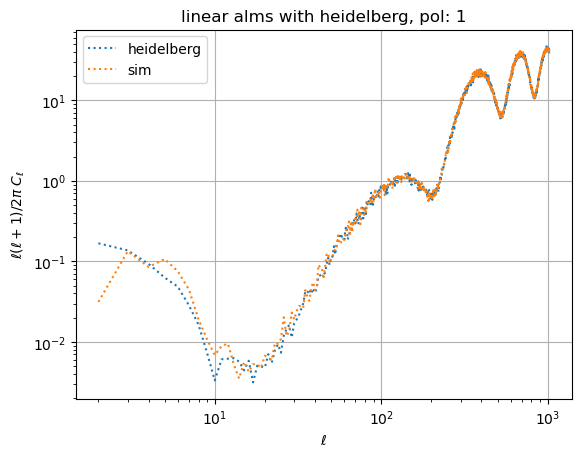

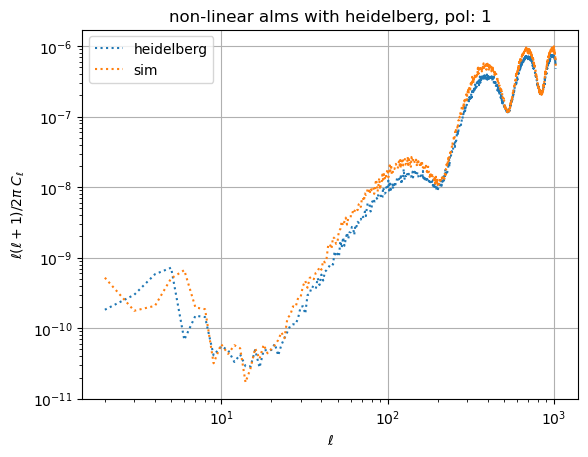

In [194]:
from scripts.generator import generate_alm, generate_alm_ng

core = Core(
    [
        "settings/heidelberg.json",
        "--nsims",
        "1",
        "--narray",
        "1",
        "--fnl_range",
        "-10",
        "10",
        "--no-noise",
        "--pols",
    ]
)

alm_l = generate_alm(core)
alm_ng = generate_alm_ng(core, alm_l)
# fnls = core.rng.uniform(core.fnl_min, core.fnl_max, core.fnl_shape)
# alms = alm_l + fnls[:, np.newaxis, :] * alm_ng
# alms = remove_mono_dipole(alms)

idx = str(1).zfill(4)
base1 = f"data/heidelberg/alm_l_{idx}_v3.fits"
base2 = f"data/heidelberg/alm_nl_{idx}_v3.fits"

# these load the TT, EE, TE alms
alm_heidelberg_l = np.array(hp.read_alm(base1, hdu=(1, 2, 3)))
alm_heidelberg_nl = np.array(hp.read_alm(base2, hdu=(1, 2, 3)))

t_scale = core.cosmo.camb_params.TCMB * 1e6
alm_heidelberg_l *= t_scale
alm_heidelberg_nl *= t_scale
# alm_l *= t_scale
# alm_ng *= t_scale

for pol in range(core.npol):
    lin = [alm_heidelberg_l[pol], alm_l[0, pol]]
    plot_cl_alm(
        lin,
        labels=["heidelberg", "sim"],
        title=f"linear alms with heidelberg, pol: {pol}",
        plot_func=plt.loglog,
    )
    nonlin = [alm_heidelberg_nl[pol], alm_ng[0, pol]]
    plot_cl_alm(
        nonlin,
        labels=["heidelberg", "sim"],
        title=f"non-linear alms with heidelberg, pol: {pol}",
        plot_func=plt.loglog,
    )

In [195]:
# stop

## Setup

In [196]:
from scripts.generator import generate_alm, generate_alm_ng

core = Core(
    [
        "settings/l191_n64.json",
        # "settings/l256_n64.json",
        # "settings/l500_n128.json",
        # "settings/l2000_n2048.json",
        "--nsims",
        "100",
        "--narray",
        "1",
        "--fnl_range",
        "-10",
        "10",
        "--no-noise",
        # "--lensing",
        "--pols",
    ]
)

20-Jul-24 19:33:19 - scripts.core - DEBUG - Parsing CLI args: ['settings/l191_n64.json', '--nsims', '100', '--narray', '1', '--fnl_range', '-10', '10', '--no-noise', '--pols']
20-Jul-24 19:33:19 - scripts.core - INFO - Loading settings from file settings/l191_n64.json
20-Jul-24 19:33:19 - scripts.core - DEBUG - Forcing setting 'nsims' to '100' due to CLI
20-Jul-24 19:33:19 - scripts.core - DEBUG - Forcing setting 'narray' to '1' due to CLI
20-Jul-24 19:33:19 - scripts.core - DEBUG - Forcing setting 'fnl_range' to '[-10.0, 10.0]' due to CLI
20-Jul-24 19:33:19 - scripts.core - DEBUG - Forcing setting 'noise' to 'False' due to CLI
20-Jul-24 19:33:19 - scripts.core - DEBUG - Forcing setting 'pols' to 'True' due to CLI
20-Jul-24 19:33:19 - scripts.core - DEBUG - Found non-default value for 'cosmo_params': {'H0': 67.4, 'As': 2.457e-09, 'ns': 0.9649, 'ombh2': 0.0224, 'omch2': 0.12, 'tau': 0.054, 'lmax': 191} (default: {'As': 2.13e-09, 'ns': 0.9624, 'pivot_scalar': 0.05, 'lmax': 500})
20-Jul-2

## Alm

This code generates the alms

$$a_{\ell m} = a_{\ell m}^{{G}} + f_{NL}^X a_{\ell m}^{NG}$$
with
$$a_{\ell m}^{NG,loc'} = \int dr r^2 \left[ \alpha_\ell(r)\left(\int d^2 \hat{n} Y_{\ell m}^\star (\hat{n}) B(r,\hat{n})^2 \right)\right]$$
and
$$\alpha_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^2 \Delta_\ell^T(k) j_\ell(k r)$$
$$\beta_\ell(r)=\frac{2}{\pi} \int_0^\infty dk k^{-1} \Delta_\phi \Delta_\ell^T(k) j_\ell(k r)$$
$$B(r, \hat{n}) = \sum_{\ell,m} \frac{\beta_\ell (r)}{C_\ell} a_{\ell m} Y_{\ell m}$$
where $\Delta_\phi$ is primordial normalization, $\Delta_\ell^T(k)$ is the transfer function, $j_\ell(k r)$ are the spherical bessel functions   

In [197]:
from scripts.generator import generate_alm, generate_alm_ng

In [198]:
alm_l = generate_alm(core)
alm_ng = generate_alm_ng(core, alm_l)

fnls = core.rng.uniform(core.fnl_min, core.fnl_max, core.fnl_shape)

alms = alm_l + fnls[:, np.newaxis, :] * alm_ng
alms = remove_mono_dipole(alms)

20-Jul-24 19:33:20 - scripts.generator - DEBUG - Setting up the non-gaussian alms
20-Jul-24 19:33:29 - scripts.generator - DEBUG - Done
20-Jul-24 19:33:29 - scripts.generator - DEBUG - Using temp folder for Alm_ng generation: /lustre/scratch/client/users/stevensonb


Alm_ng:   0%|          | 0/100 [00:00<?, ?it/s]

In [ ]:
for pol in range(core.npol):
    plot_cl_alm(
        alm_l[0, pol],
        title=f"linear alms with heidelberg, pol: {pol}",
        labels="sim",
        plot_camb=True,
        camb_cls=core.c_ells[pol],
        plot_noise=False,
        camb_noise=core.noise_ell[pol],
        plot_full_camb=True,
        camb_beam=core.beam_ell[pol],
    )

    plot_cl_alm(
        alm_ng[0, pol],
        labels="sim",
        title=f"non-linear alms with heidelberg, pol: {pol}",
    )

In [ ]:
for pol in range(core.npol):
    plot_cl_alm(
        alms[0, pol],
        title=f"alms final, pol: {pol}",
        plot_camb=True,
        camb_cls=core.c_ells[pol],
        plot_noise=False,
        camb_noise=core.noise_ell[pol],
        plot_full_camb=True,
        camb_beam=core.beam_ell[pol],
    )

## Lensing and Patching

In [ ]:
# just some tests
if core.lensing:
    cl_phi = core.cosmo._camb_data.get_lens_potential_cls(  # type: ignore
        core.max_l, CMB_unit="muK", raw_cl=True
    )

    plm = lenspyx.utils_hp.synalm(cl_phi[:, 0], lmax=core.max_l, mmax=None)

    # transform the lensing potential into spin-1 deflection field
    fl = np.sqrt(np.arange(core.max_l + 1) * np.arange(1, core.max_l + 2))
    dlm = lenspyx.utils_hp.almxfl(plm, fl, mmax=None, inplace=False)

    geom_info = ("healpix", {"nside": core.nside})
    geom = lenspyx.get_geom(geom_info)

    Tunl = geom.alm2map(alms[0, 0], core.max_l, core.max_l, nthreads=core.n_cpus)
    Tlen, Qlen, Ulen = lenspyx.alm2lenmap(alms[0], dlm, geometry=geom_info, verbose=1)

    hp.mollview(Tunl, title="unlensed T map")
    hp.mollview(Tlen, title="lensed T map")
    hp.mollzoom(Tlen - Tunl, title="lensed - unlensed")
    hp.mollzoom(Qlen, title="lensed Q map")
    hp.mollzoom(Ulen, title="lensed U map")

    T = geom.map2alm(Tlen, core.lmax, core.lmax, nthreads=core.n_cpus)
    E, B = geom.map2alm_spin(
        [Qlen, Ulen], 2, core.lmax, core.lmax, nthreads=core.n_cpus
    )
    tlm_len = geom.map2alm(Tlen, core.lmax, core.lmax, nthreads=core.n_cpus)

    cltt_len = lenspyx.utils_hp.alm2cl(T, T, core.lmax, core.lmax, core.lmax)
    clee_len = lenspyx.utils_hp.alm2cl(E, E, core.lmax, core.lmax, core.lmax)
    clbb_len = lenspyx.utils_hp.alm2cl(B, B, core.lmax, core.lmax, core.lmax)
    ls = np.arange(2, core.lmax - 32)

    cltt_unl = core.c_ells[0]
    clee_unl = core.c_ells[1]
    clbb_unl = core.c_ells[2]

    plt.plot(ls, cltt_len[ls] / cltt_unl[ls], label="TT")
    # plt.plot(ls, cltt_len[ls] / cltt_unl[ls], c="k")

    plt.plot(ls, clee_len[ls] / clee_unl[ls], label="EE")
    # plt.plot(ls, clee_len[ls] / clee_unl[ls], c="k", ls="--")
    # plt.ylim(0.8, 1.4)
    plt.legend()
    plt.show()

    plt.loglog(ls, clbb_len[ls], label="BB")
    plt.plot(ls, clbb_unl[ls], c="k")
    plt.legend()
    plt.show()

In [ ]:
cl_phi = core.cosmo._camb_data.get_lens_potential_cls(  # type: ignore
    core.lmax, CMB_unit="muK", raw_cl=True
)
plm = lenspyx.utils_hp.synalm(cl_phi[:, 0], lmax=core.lmax, mmax=None)

# transform the lensing potential into spin-1 deflection field
fl = np.sqrt(np.arange(core.nell) * np.arange(1, core.nell + 1))
dlm = lenspyx.utils_hp.almxfl(plm, fl, mmax=None, inplace=False)

geom_info = ("healpix", {"nside": core.nside})
geom = lenspyx.get_geom(geom_info)

ps_rad = np.deg2rad(core.patch_side_deg)
res = ps_rad / core.nside

fs_shape, fs_wcs = enmap.fullsky_geometry(res, proj="car")
if core.use_pols:
    fs_shape = (core.npol + 1,) + fs_shape
else:
    fs_shape = (core.npol,) + fs_shape
fs_map = enmap.zeros(fs_shape, fs_wcs)

patch_shapes = []
patch_wcss = []
for counter in range(core.npatches // 2):
    # [[dec_min,ra_min],[dec_max,ra_max]]
    top = [[0, ps_rad * counter], [ps_rad, ps_rad * (counter + 1)]]
    gs, w = enmap.geometry(pos=top, res=res, proj="car")
    patch_shapes.append(gs)
    patch_wcss.append(w)

    bottom = [[-ps_rad, ps_rad * counter], [0, ps_rad * (counter + 1)]]
    gs, w = enmap.geometry(pos=bottom, res=res, proj="car")
    patch_shapes.append(gs)
    patch_wcss.append(w)

In [ ]:
# convert the map into a pixell map to allow for projection
if core.lensing:
    tmp_pols = 3 if core.use_pols else 1
    patches = np.empty(
        (core.nsims, core.npatches, tmp_pols, core.nside, core.nside),
        dtype=core.r_dtype,
    )
    alm_lensed = np.empty((core.nsims, tmp_pols, core.nelem), dtype=core.c_dtype)
    for sim in range(core.nsims):
        lens_map = lenspyx.alm2lenmap(
            alms[sim], dlm, geometry=geom_info, nthreads=core.n_cpus
        )

        alm_lensed[sim, 0] = geom.map2alm(
            lens_map[0], core.lmax, core.lmax, nthreads=core.n_cpus
        )
        if core.npol > 1:
            alm_lensed[sim, 1:] = geom.map2alm_spin(
                lens_map[1:], 2, core.lmax, core.lmax, nthreads=core.n_cpus
            )

        pixell_map = reproject.healpix2map(lens_map, fs_shape, fs_wcs, core.lmax)

        # cut the patches
        for i in range(core.npatches):
            ret = pixell_map.project(patch_shapes[i], patch_wcss[i])
            patches[sim, i] = pixell_map.project(patch_shapes[i], patch_wcss[i])

else:
    patches = np.empty(
        (core.nsims, core.npatches, core.npol, core.nside, core.nside),
        dtype=core.r_dtype,
    )

    for sim in range(core.nsims):
        car_map = curvedsky.alm2map(alms[sim], fs_map, nthread=core.n_cpus, copy=True)

        for i in range(core.npatches):
            patch = car_map.project(patch_shapes[i], patch_wcss[i])  # type: ignore
            patches[sim, i] = patch[:2]

In [ ]:
for pol in range(core.npol):
    plot_patches(patches[0, :, pol], title=f"Pol {pol}")

## Estimator

In [ ]:
from ksw import Cosmology, Shape, Data
import camb
from scripts.estimator import icov_func, conv_beam_func

In [ ]:
cosmo_params = core.cosmo_params
cosmo = Cosmology(camb.set_params(**cosmo_params))
cosmo.compute_transfer(core.max_l)
cosmo.compute_c_ell()

noise = core.noise_ell[: core.npol]
beam = core.beam_ell[: core.npol]
c_ells = core.c_ells[: core.npol]

loc_shape = Shape.prim_local(cosmo_params["ns"], cosmo_params["pivot_scalar"])
cosmo.add_prim_reduced_bispectrum(loc_shape, core.radii)

icov = icov_func(beam, noise, c_ells)

nnnnoise = core.noise_ell[[0, 1, 3]] if core.use_pols else core.noise_ell[0]
data = Data(core.lmax, nnnnoise, beam, core.pols, cosmo)

ksw = KSW_joblib(
    cosmo.red_bispectra,
    icov,
    conv_beam_func(core, core.npol),
    core.lmax,
    core.pols,
    core.precision,
)

# uncomment to remove the mc file to regenerated
if os.path.exists(core.mc_file):
    os.remove(core.mc_file)

In [ ]:
theta_batch = int(np.floor(1.5 * core.lmax + 1)) // core.n_cpus

if False and os.path.exists(core.mc_file):
    print("Loading KSW state from ", core.mc_file)
    ksw.start_from_read_state(core.mc_file, None)
else:
    n_steps = 200
    # step_alms = generate_alm(core, n_steps)

    def alm_step_loader(idx):
        return data.compute_alm_sim(core.lensing)

    ksw.step_batch(alm_step_loader, range(n_steps), theta_batch=theta_batch)

    print("Saving KSW state to", core.mc_file)
    ksw.write_state(core.mc_file)

In [ ]:
fisher = ksw.compute_fisher()
print(f"Fisher: {fisher}, standard deviation: {np.sqrt(1 / fisher)}")

In [ ]:
pbar = tqdm(total=core.nsims, desc="Computing estimates")


def alm_loader(i):
    pbar.update(1)
    if core.lensing:
        return alm_lensed[i, : core.npol]
    else:
        return alms[i, : core.npol]


idxs = range(alms.shape[0])

estimates = ksw.compute_estimate_batch(
    alm_loader, idxs, theta_batch=theta_batch, fisher=fisher
)
pbar.close()

In [ ]:
diff = estimates - fnls[:, 0]
std_dev = np.sqrt(1 / fisher)
sem = std_dev / np.sqrt(len(diff))
logger.info("Standard deviation: %s, SEM: %s", std_dev, sem)
for i in range(3):
    within = np.sum(np.abs(diff) < ((i + 1) * std_dev))
    percentage = within / len(diff) * 100
    within_error = np.sum(np.abs(diff) < ((i + 1) * (std_dev + sem)))
    percentage_error = within_error / len(diff) * 100
    print(
        f"{percentage}% are within {i+1} standard deviations, and {percentage_error}% are within standard deviations with error."
    )

plot_predictions(fnls, estimates, fisher=fisher)
plot_histogram(fnls, estimates)